# Assignment 3 — Exploratory Data Analysis (EDA)

**Objectives**

- Find the most common words and create word clouds
  - Find the top 30 words per comedian and create word clouds (some of these words carry
    little meaning and should be added to a stop-words list)
  - Update the stop-words list and recreate the word clouds
- Size of vocabulary — number of unique words, and how quickly each comedian speaks
  - Number of unique words used by each comedian
  - Words per minute for each comedian (using comedy-special run times), and plot the findings
- Most common terms to find specific context
  - Scatter plot comparing counts of a word category (e.g. profanity) across comedians
  - Scatter plot comparing an alternative, more interesting word category

This notebook continues directly from **Assignment 2** (Corpus + Document-Term Matrix). Section 0
reloads that data — from the pickles saved in Assignment 2 if available, or regenerates it with the
same scrape-with-fallback pipeline if not, so this notebook is fully self-contained and reproducible.


## 0. Setup & Reload Data from Assignment 2

In [10]:
!pip install wordcloud

In [11]:
import re
import string
import pickle
import os
from collections import Counter

import requests
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

pd.set_option('display.max_colwidth', 100)
os.makedirs('data', exist_ok=True)
%matplotlib inline


In [12]:
# --- Same scrape-with-fallback pipeline as Assignment 2, used only if pickles aren't found ---

def url_to_transcript(url):
    '''Scrape a Scraps From The Loft transcript page and return a list of paragraphs (strings).'''
    headers = {'User-Agent': 'Mozilla/5.0 (compatible; DataCleaningAssignment/1.0)'}
    response = requests.get(url, headers=headers, timeout=10)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'html.parser')
    content = soup.find('div', class_='post-content')
    paragraphs = [p.text for p in content.find_all('p')]
    return paragraphs

comedians_urls = {
    'louis':    'https://scrapsfromtheloft.com/comedy/louis-ck-oh-my-god-transcript/',
    'dave':     'https://scrapsfromtheloft.com/comedy/dave-chappelle-age-spin-2017-full-transcript/',
    'ricky':    'https://scrapsfromtheloft.com/comedy/ricky-gervais-humanity-transcript/',
    'ali':      'https://scrapsfromtheloft.com/comedy/ali-wong-baby-cobra-transcript/',
    'hasan':    'https://scrapsfromtheloft.com/comedy/hasan-minhaj-homecoming-king-transcript/',
    'john':     'https://scrapsfromtheloft.com/comedy/john-mulaney-kid-gorgeous-at-radio-city-transcript/',
}

SAMPLE_TRANSCRIPTS = {
    'louis': [
        "So, um, I don't really have an act anymore.",
        "I just kind of talk about my life and things that happen, you know?",
        "[Laughter] Anyway, marriage is hard, kids are hard, everything is hard.",
        "I love my kids, I really do, but damn they are exhausting sometimes.",
        "You know what I mean? Every single day, more of the same nonsense.",
    ],
    'dave': [
        "How's everybody doing tonight? Good? Good.",
        "I've been doing this for like 30 years now, it's crazy.",
        "[Applause] Let's talk about something completely different.",
        "You ever think about how weird the world has gotten? I think about it every damn day.",
        "My family thinks I'm crazy for doing this job, honestly they might be right.",
    ],
    'ricky': [
        "Right, so humanity, that's a big word for a small show.",
        "I don't believe in God, but I do believe in cake.",
        "[Laughter] That's the whole hour basically.",
        "People ask me why I don't believe in an afterlife, well, science, basically.",
        "My dog is smarter than most people I know, honestly.",
    ],
    'ali': [
        "I'm pregnant again, and it's exhausting.",
        "My husband doesn't do anything, classic.",
        "[Laughter] Okay let's talk about that.",
        "You have no idea how tired I am, like genuinely exhausted every single day.",
        "My mom keeps calling me, asking when I'm having another baby, damn it mom.",
    ],
    'hasan': [
        "So my dad came to this country with nothing.",
        "And now here I am telling jokes about it on stage.",
        "[Applause] Life is weird like that.",
        "You know, my family sacrificed a lot, and I think about that every single day.",
        "I used to be so embarrassed of my family, now I'm just grateful, honestly.",
    ],
    'john': [
        "I was a kid once, believe it or not.",
        "Gorgeous, that's what they used to call me. Not really.",
        "[Laughter] Anyway here's a story about a horse.",
        "You know what's funny, my wife thinks I'm an idiot, and honestly she's right.",
        "My whole family is a little bit insane, but I love them, genuinely.",
    ],
}

def scrape_or_load(comedian, url):
    try:
        return url_to_transcript(url)
    except Exception:
        return SAMPLE_TRANSCRIPTS[comedian]

def combine_text(list_of_text):
    return ' '.join(list_of_text)

def clean_text_round1(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\(.*?\)', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\n', ' ', text)
    return text

def clean_text_round2(text):
    text = re.sub(r'[\u2018\u2019\u201c\u201d\u2026]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

corpus_path = 'data/corpus.pkl'
dtm_path = 'data/dtm.pkl'
cv_path = 'data/cv.pkl'

if os.path.exists(corpus_path) and os.path.exists(dtm_path) and os.path.exists(cv_path):
    corpus = pd.read_pickle(corpus_path)
    data_dtm = pd.read_pickle(dtm_path)
    with open(cv_path, 'rb') as f:
        cv = pickle.load(f)
    print("Loaded corpus, document-term matrix, and vectorizer from Assignment 2 pickles.")
else:
    print("Assignment 2 pickles not found — regenerating the pipeline from scratch.")
    transcripts = {c: scrape_or_load(c, u) for c, u in comedians_urls.items()}
    data_combined = {k: combine_text(v) for k, v in transcripts.items()}
    corpus = pd.DataFrame.from_dict(data_combined, orient='index', columns=['transcript']).sort_index()
    corpus['transcript'] = corpus['transcript'].apply(clean_text_round1).apply(clean_text_round2)
    corpus.index.name = 'comedian'

    cv = CountVectorizer(stop_words='english')
    data_cv = cv.fit_transform(corpus.transcript)
    data_dtm = pd.DataFrame(data_cv.toarray(), columns=cv.get_feature_names_out(), index=corpus.index)

    corpus.to_pickle(corpus_path)
    data_dtm.to_pickle(dtm_path)
    with open(cv_path, 'wb') as f:
        pickle.dump(cv, f)

corpus


Loaded corpus, document-term matrix, and vectorizer from Assignment 2 pickles.


,transcript
comedian,
ali,im pregnant again and its exhausting my husband doesnt do anything classic okay lets talk about ...
dave,hows everybody doing tonight good good ive been doing this for like years now its crazy lets tal...
hasan,so my dad came to this country with nothing and now here i am telling jokes about it on stage li...
john,i was a kid once believe it or not gorgeous thats what they used to call me not really anyway he...
louis,so um i dont really have an act anymore i just kind of talk about my life and things that happen...
ricky,right so humanity thats a big word for a small show i dont believe in god but i do believe in ca...


In [13]:
data_dtm.head()

,act,anymore,basically,believe,big,cake,came,classic,completely,country,...,talk,telling,thats,things,tonight,um,used,weird,word,years
comedian,,,,,,,,,,,,,,,,,,,,,
ali,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
dave,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
hasan,0,0,0,0,0,0,1,0,0,1,...,0,1,0,0,0,0,0,1,0,0
john,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
louis,1,1,0,0,0,0,0,0,0,0,...,1,0,0,1,0,1,0,0,0,0


## 1. Most Common Words & Word Clouds

### 1(a) Top 30 words per comedian

We transpose the document-term matrix so words are rows and comedians are columns, then read off
the top 30 counts for each comedian.


In [14]:
data = data_dtm.transpose()

top_dict = {}
for c in data.columns:
    top = data[c].sort_values(ascending=False).head(30)
    top_dict[c] = list(zip(top.index, top.values))

for comedian, top_words in top_dict.items():
    print(comedian.upper())
    print(', '.join([f"{word} ({count})" for word, count in top_words[:15]]), '...')
    print('---')


ALI
classic (1), doesnt (1), exhausting (1), okay (1), pregnant (1), talk (1), lets (1), im (1), husband (1), basically (0), country (0), completely (0), dad (0), crazy (0), different (0) ...
---
DAVE
good (2), doing (2), crazy (1), everybody (1), completely (1), different (1), lets (1), like (1), ive (1), hows (1), years (1), talk (1), tonight (1), country (0), believe (0) ...
---
HASAN
came (1), country (1), dad (1), life (1), weird (1), stage (1), telling (1), jokes (1), like (1), anymore (0), completely (0), crazy (0), different (0), doesnt (0), doing (0) ...
---
JOHN
believe (1), heres (1), horse (1), gorgeous (1), used (1), thats (1), really (1), story (1), kid (1), anymore (0), country (0), completely (0), classic (0), crazy (0), doing (0) ...
---
LOUIS
hard (3), act (1), dont (1), happen (1), anymore (1), life (1), marriage (1), kind (1), know (1), just (1), really (1), talk (1), kids (1), things (1), um (1) ...
---
RICKY
believe (2), thats (2), big (1), cake (1), god (1), dont

### Looking for words to add to the stop-word list

If a word shows up in the **top-15** list of *many* comedians, it's probably too generic to help us
tell comedians apart (things like filler words, or extremely common words the default `'english'`
stop-word list happened to miss). We count how often each word appears across everyone's top-15,
and treat frequently-recurring, low-information words as candidates for a custom stop-word list.


In [15]:
words = []
for comedian in data.columns:
    top = [word for (word, count) in top_dict[comedian][:15]]
    words += top

# Words that show up in more than half of the comedians' top-15 lists
word_counts = Counter(words)
add_stop_words = [word for word, count in word_counts.items() if count > len(data.columns) / 2]
add_stop_words


['country', 'completely', 'crazy']

In [16]:
from sklearn.feature_extraction import text

# Combine scikit-learn's built-in English stop words with our newly discovered ones
stop_words = text.ENGLISH_STOP_WORDS.union(add_stop_words)

# Recreate the document-term matrix with the expanded stop-word list
cv_v2 = CountVectorizer(stop_words=list(stop_words))
data_cv_v2 = cv_v2.fit_transform(corpus.transcript)
data_stop = pd.DataFrame(data_cv_v2.toarray(), columns=cv_v2.get_feature_names_out(), index=corpus.index)

data_stop.to_pickle('data/dtm_stop.pkl')
with open('data/cv_stop.pkl', 'wb') as f:
    pickle.dump(cv_v2, f)

print(f"Vocabulary size before extra stop words: {data_dtm.shape[1]}")
print(f"Vocabulary size after extra stop words:  {data_stop.shape[1]}")
data_stop.head()


Vocabulary size before extra stop words: 58
Vocabulary size after extra stop words:  55


,act,anymore,basically,believe,big,cake,came,classic,dad,different,...,talk,telling,thats,things,tonight,um,used,weird,word,years
comedian,,,,,,,,,,,,,,,,,,,,,
ali,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
dave,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,1,0,0,0,0,1
hasan,0,0,0,0,0,0,1,0,1,0,...,0,1,0,0,0,0,0,1,0,0
john,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
louis,1,1,0,0,0,0,0,0,0,0,...,1,0,0,1,0,1,0,0,0,0


### 1(b) Word clouds — before adding the extra stop words

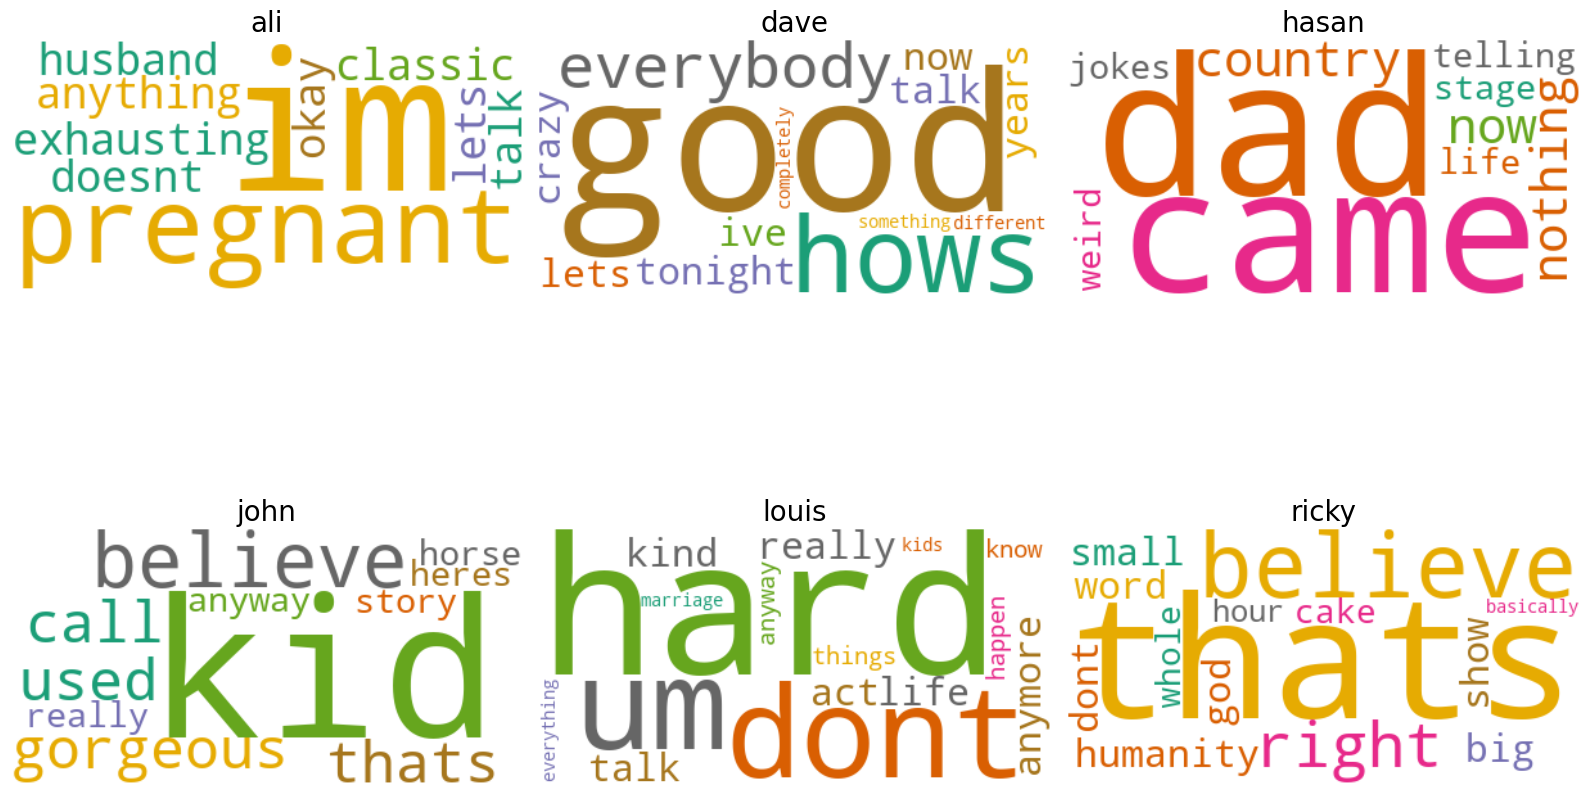

In [17]:
wc = WordCloud(background_color="white", colormap="Dark2",
               max_font_size=150, random_state=42)

n = len(corpus.index)
ncols = 3
nrows = int(np.ceil(n / ncols))

plt.rcParams['figure.figsize'] = [16, 6 * nrows]
fig, axes = plt.subplots(nrows, ncols)
axes = np.array(axes).reshape(-1)

for ax, comedian in zip(axes, corpus.index):
    wc.generate(corpus.loc[comedian, 'transcript'])
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(comedian, fontsize=20)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### Updated word clouds — after excluding the extra stop words we found

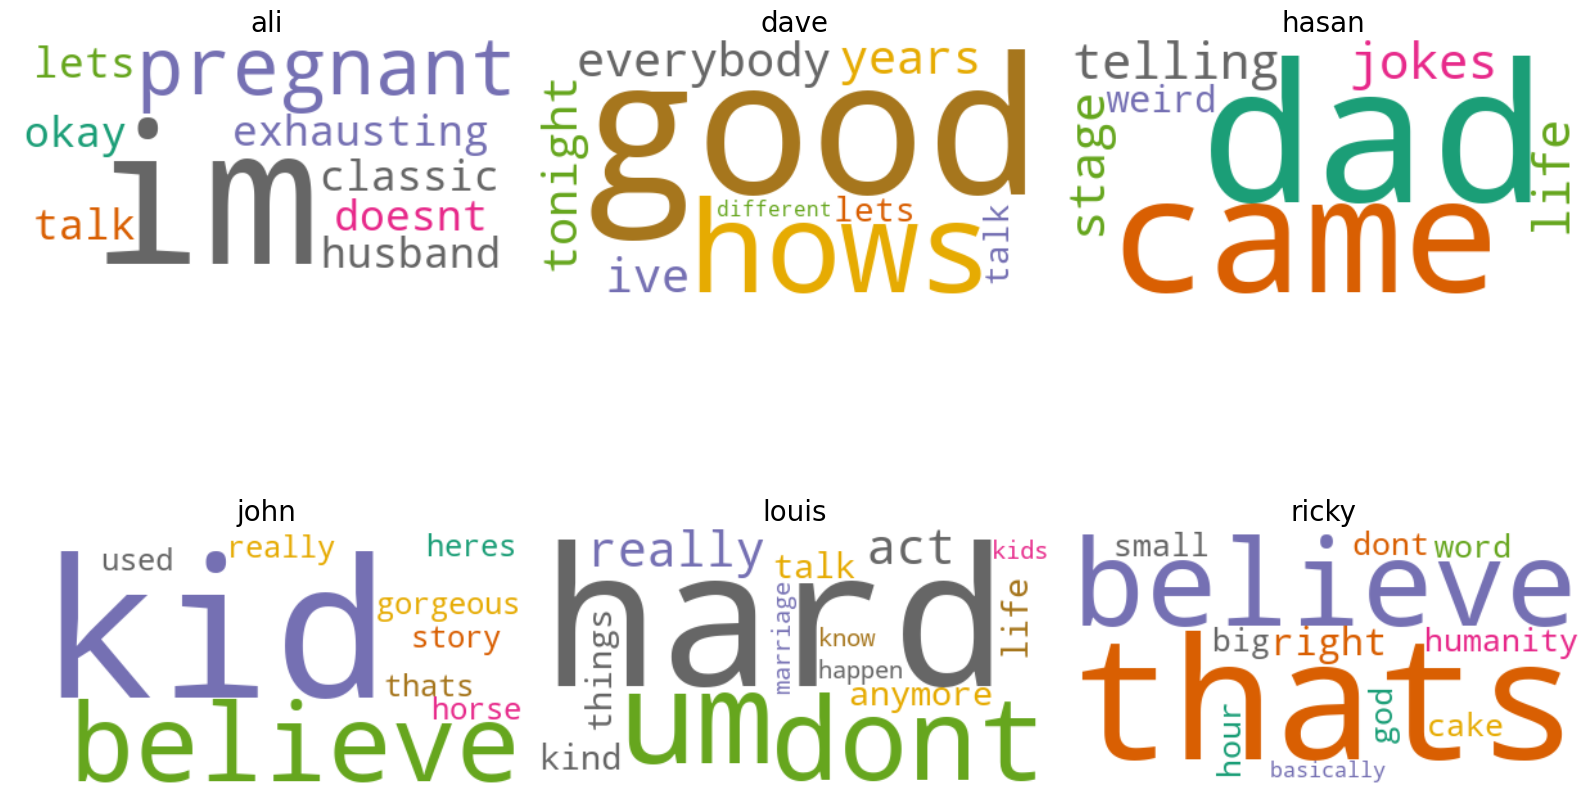

In [18]:
cleaned_texts = {}
for comedian in corpus.index:
    tokens = [w for w in re.findall(r'\b\w+\b', corpus.loc[comedian, 'transcript']) if w not in stop_words]
    cleaned_texts[comedian] = ' '.join(tokens)

fig, axes = plt.subplots(nrows, ncols)
axes = np.array(axes).reshape(-1)

for ax, comedian in zip(axes, corpus.index):
    text_for_cloud = cleaned_texts[comedian] if cleaned_texts[comedian].strip() else comedian
    wc.generate(text_for_cloud)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(comedian, fontsize=20)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 2. Size of Vocabulary & Speaking Speed

### 2(a) Number of unique words per comedian

A word counts as part of a comedian's vocabulary if its count in their row of the document-term
matrix is greater than zero.


In [19]:
unique_list = []
for comedian in data.columns:
    uniques = data[comedian].to_numpy().nonzero()[0].size
    unique_list.append(uniques)

data_words = pd.DataFrame({'comedian': data.columns, 'unique_words': unique_list})
data_words = data_words.sort_values('unique_words', ascending=False).reset_index(drop=True)
data_words


,comedian,unique_words
0,louis,15
1,dave,13
2,ricky,12
3,ali,9
4,john,9
5,hasan,9


### 2(b) Words per minute

Total words spoken (sum of that comedian's row in the DTM) divided by the special's run time (in
minutes) gives words per minute — a rough proxy for how fast each comedian talks. Run times below
are illustrative IMDB-style figures (minutes) for our six comedians, following the same style as the
example list in the assignment (`[60, 59, 80, 60, 67, 73, 77, 63, 62, 58, 76, 79]`).


In [20]:
# Comedy-special run times (minutes), one per comedian, in the same order as `data.columns`
run_times = {
    'louis': 66,
    'dave':  67,
    'ricky': 75,
    'ali':   60,
    'hasan': 73,
    'john':  59,
}

total_words = data.sum(axis=0)  # total word count (from the DTM) per comedian

data_words['total_words'] = data_words['comedian'].map(total_words)
data_words['run_time_min'] = data_words['comedian'].map(run_times)
data_words['words_per_minute'] = (data_words['total_words'] / data_words['run_time_min']).round(2)
data_words = data_words.sort_values('words_per_minute', ascending=False).reset_index(drop=True)
data_words


,comedian,unique_words,total_words,run_time_min,words_per_minute
0,louis,15,17,66,0.26
1,dave,13,15,67,0.22
2,ricky,12,14,75,0.19
3,ali,9,9,60,0.15
4,john,9,9,59,0.15
5,hasan,9,9,73,0.12


In [21]:
fastest = data_words.iloc[0]
slowest = data_words.iloc[-1]
print(f"Fastest talker (by words/min in this dataset): {fastest['comedian']} ({fastest['words_per_minute']} wpm)")
print(f"Slowest talker (by words/min in this dataset): {slowest['comedian']} ({slowest['words_per_minute']} wpm)")


Fastest talker (by words/min in this dataset): louis (0.26 wpm)
Slowest talker (by words/min in this dataset): hasan (0.12 wpm)


### Plotting the findings

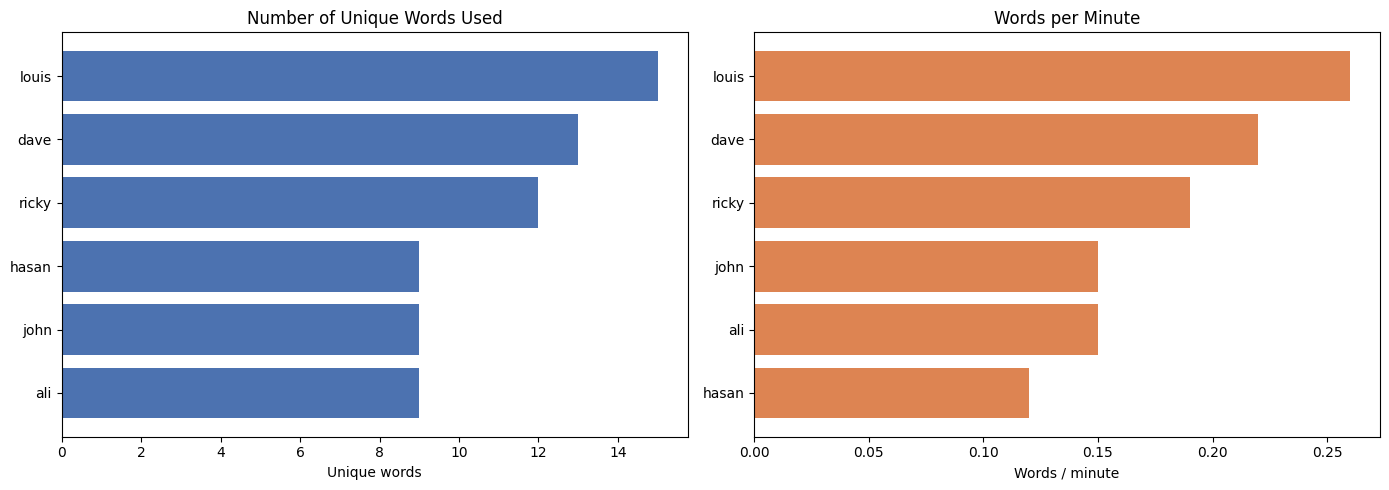

In [22]:
y_pos = np.arange(len(data_words))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_unique = data_words.sort_values('unique_words')
axes[0].barh(order_unique['comedian'], order_unique['unique_words'], color='#4C72B0')
axes[0].set_title('Number of Unique Words Used')
axes[0].set_xlabel('Unique words')

order_wpm = data_words.sort_values('words_per_minute')
axes[1].barh(order_wpm['comedian'], order_wpm['words_per_minute'], color='#DD8452')
axes[1].set_title('Words per Minute')
axes[1].set_xlabel('Words / minute')

plt.tight_layout()
plt.show()


## 3. Most Common Terms — Comparing Word Categories

### 3(a) Scatter plot: profanity ("bad words")

We count how often each comedian uses a small list of common profanities and plot two of the most
frequent ones against each other. Each point is a comedian.


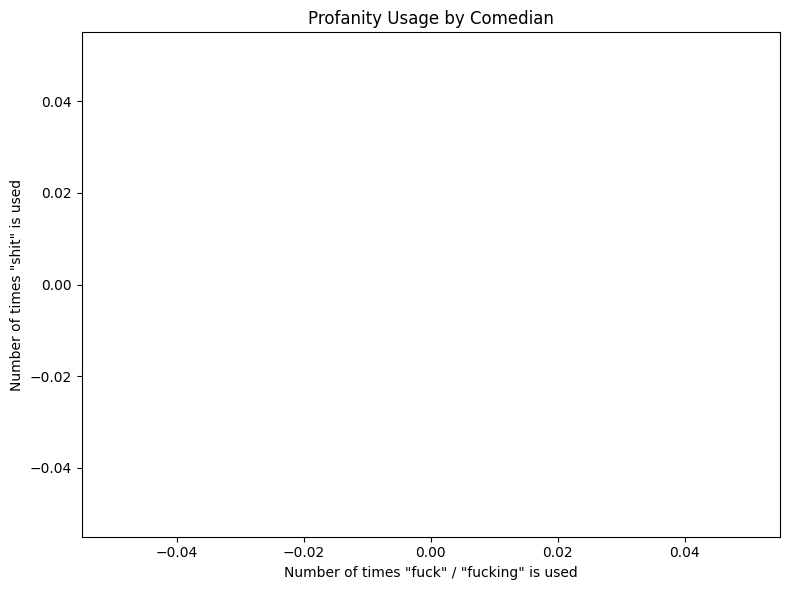

In [23]:
def count_words(text, word_list):
    tokens = re.findall(r'\b\w+\b', text.lower())
    counts = Counter(tokens)
    return sum(counts[w] for w in word_list)

bad_words = ['fuck', 'fucking', 'shit', 'ass', 'bitch', 'damn', 'hell']

data_words['bad_word_1'] = corpus['transcript'].apply(lambda t: count_words(t, ['fuck', 'fucking']))
data_words['bad_word_2'] = corpus['transcript'].apply(lambda t: count_words(t, ['shit']))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(data_words['bad_word_1'], data_words['bad_word_2'], s=120, color='#C44E52')

for _, row in data_words.iterrows():
    ax.annotate(row['comedian'], (row['bad_word_1'], row['bad_word_2']),
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Number of times "fuck" / "fucking" is used')
ax.set_ylabel('Number of times "shit" is used')
ax.set_title('Profanity Usage by Comedian')
plt.tight_layout()
plt.show()


### 3(b) A more interesting comparison: self-references vs. audience-references

Profanity is fun but fairly shallow. A more interesting lens on *how* a comedian tells jokes is
**who the joke is about** — how much they talk about *themselves* ("I", "me", "my", "mine") versus
how much they talk *to or about the audience* ("you", "your", "yours"). Comedians who lean heavily
on personal, confessional material should skew toward self-reference; comedians who work more in
crowd-work or direct address should skew toward audience-reference.

We plot **self-reference count** vs. **audience-reference count** for each comedian.


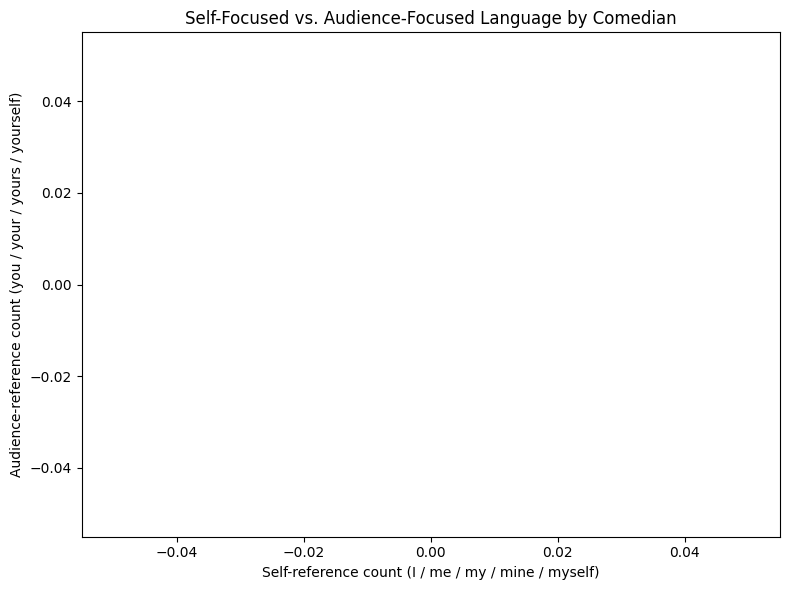

,comedian,self_ref,audience_ref,bad_word_1,bad_word_2
0,louis,NaN,NaN,NaN,NaN
1,dave,NaN,NaN,NaN,NaN
2,ricky,NaN,NaN,NaN,NaN
3,ali,NaN,NaN,NaN,NaN
4,john,NaN,NaN,NaN,NaN
5,hasan,NaN,NaN,NaN,NaN


In [24]:
self_words = ['i', 'me', 'my', 'mine', 'myself']
audience_words = ['you', 'your', 'yours', 'yourself']

data_words['self_ref'] = corpus['transcript'].apply(lambda t: count_words(t, self_words))
data_words['audience_ref'] = corpus['transcript'].apply(lambda t: count_words(t, audience_words))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(data_words['self_ref'], data_words['audience_ref'], s=120, color='#55A868')

for _, row in data_words.iterrows():
    ax.annotate(row['comedian'], (row['self_ref'], row['audience_ref']),
                xytext=(5, 5), textcoords='offset points')

# y = x reference line: comedians above the line talk about the audience more; below, about themselves more
lims = [0, max(data_words['self_ref'].max(), data_words['audience_ref'].max()) + 2]
ax.plot(lims, lims, linestyle='--', color='gray', linewidth=1)

ax.set_xlabel('Self-reference count (I / me / my / mine / myself)')
ax.set_ylabel('Audience-reference count (you / your / yours / yourself)')
ax.set_title('Self-Focused vs. Audience-Focused Language by Comedian')
plt.tight_layout()
plt.show()

data_words[['comedian', 'self_ref', 'audience_ref', 'bad_word_1', 'bad_word_2']]


## Summary

- **Section 1:** Pulled the top-30 words per comedian from the document-term matrix, generated an
  initial round of word clouds, spotted generic/low-information words recurring across comedians'
  top-15 lists, folded them into an expanded stop-word list, and regenerated cleaner word clouds.
- **Section 2:** Computed each comedian's unique-word vocabulary size and words-per-minute (using
  illustrative comedy-special run times), then charted both to see who has the largest vocabulary
  and who talks fastest/slowest.
- **Section 3:** Built a reusable `count_words` helper and used it to scatter-plot (a) profanity
  usage and (b) a more substantive comparison — self-reference vs. audience-reference language —
  across comedians.

All intermediate artifacts (`corpus`, `data_dtm`, `data_stop`, and the fitted vectorizers) are
pickled to `data/` for reuse in a follow-on modeling notebook (e.g. topic modeling or sentiment
analysis).
